<a href="https://colab.research.google.com/github/AlfredoQuintellaP/CSC_4MI04/blob/main/TP3_notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
%matplotlib inline
import matplotlib.pyplot as plt
import itertools
import numpy as np
import time
import pathlib


# TP3 — Classification d'images par CNN sur CIFAR10

Ce notebook implémente et évalue des réseaux de neurones convolutifs (CNN) pour la classification d'images sur la base **CIFAR10** (10 classes, images 32×32 pixels).

Il est structuré en quatre parties principales :
1. **Fonctions utilitaires** — affichage des matrices de confusion et des courbes d'apprentissage
2. **Chargement et préparation des données** — standardisation, découpage train/val/test
3. **Modèle de base** — expériences sur le batchsize et les optimiseurs
4. **Modèle profond** — architecture améliorée, sur-apprentissage, cartes d'activation


In [ ]:
def plot_confusion_matrix(cm, classes, normalize=False,
                          title='Matrice de confusion',
                          cmap=plt.cm.Blues):
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    plt.figure(figsize=(8, 8))
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)
    fmt = '.2f' if normalize else 'd'
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt),
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")
    plt.tight_layout()
    plt.ylabel('Vérité Terrain')
    plt.xlabel('Prédiction')


def plot_history(history, title='Courbes d\'apprentissage', save_path=None):
    """
    Plota loss e accuracy no mesmo gráfico (dois eixos Y).
    """
    acc      = history.history['acc']
    val_acc  = history.history['val_acc']
    loss     = history.history['loss']
    val_loss = history.history['val_loss']
    epochs   = range(1, len(acc) + 1)

    fig, ax1 = plt.subplots(figsize=(9, 5))

    # Eixo esquerdo — Loss
    ax1.set_xlabel('Époques')
    ax1.set_ylabel('Loss')
    l1, = ax1.plot(epochs, loss,     color='blue',       label='Train loss')
    l2, = ax1.plot(epochs, val_loss, color='green',      label='Val loss')

    # Eixo direito — Accuracy
    ax2 = ax1.twinx()
    ax2.set_ylabel('Accuracy')
    l3, = ax2.plot(epochs, acc,     color='cyan',        label='Train accuracy')
    l4, = ax2.plot(epochs, val_acc, color='red',         label='Val accuracy')

    # Legenda unificada
    plt.legend(handles=[l1, l2, l3, l4], loc='center right')
    plt.title(title)
    fig.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=150)
        print(f'Saved: {save_path}')
    plt.show()


def accuracy_per_class(model, x_test, y_test, classes):
    n_classes = len(classes)
    cm = np.zeros((n_classes, n_classes), dtype=np.int64)
    pred = np.argmax(model.predict(x_test), axis=1)
    for i in range(len(y_test)):
        cm[np.argmax(y_test[i]), pred[i]] += 1
    print(f"{'Classe':<10} {'Précision (%)':^10}")
    total_correct = 0
    for i in range(n_classes):
        class_total   = cm[i, :].sum()
        class_correct = cm[i, i]
        total_correct += class_correct
        print(f'{classes[i]:<10} {100.0 * class_correct / class_total:^10.2f}')
    test_acc = 100.0 * total_correct / len(y_test)
    print(f"Précision globale sur {len(y_test)} images de test : {test_acc:.2f} %")
    return cm


## I — Fonctions utilitaires

### `plot_confusion_matrix`
Affiche la matrice de confusion sous forme de heatmap, avec option de normalisation. Chaque cellule $(i, j)$ représente le nombre d'images de la classe $i$ prédites comme classe $j$.

### `plot_history`
Trace les courbes d'apprentissage (loss et accuracy) sur un seul graphique avec deux axes Y. Sauvegarde optionnelle via le paramètre `save_path`.

### `accuracy_per_class`
Calcule et affiche la précision par classe sur la base de test, ainsi que la précision globale.


In [ ]:
from keras.datasets import cifar10
from keras.utils import to_categorical

(x_train_full, y_train_full), (x_test_full, y_test_full) = cifar10.load_data()

classes = ('plane', 'car', 'bird', 'cat',
           'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

n_training_samples = 5000
n_other_samples    = 2000

def standardize(img_data):
    mean = np.mean(img_data, axis=(1, 2), keepdims=True)
    std  = np.std(img_data,  axis=(1, 2), keepdims=True)
    return (img_data - mean) / std

train_ids = np.random.choice(len(x_train_full), size=n_training_samples, replace=False)
other_ids = np.random.choice(len(x_test_full),  size=n_other_samples,    replace=False)

n_valid  = n_other_samples // 2
val_ids  = other_ids[:n_valid]
test_ids = other_ids[n_valid:]

x_train_initial = x_train_full[train_ids]
x_val_initial   = x_test_full[val_ids]
x_test_initial  = x_test_full[test_ids]

x_train = standardize(x_train_initial)
x_val   = standardize(x_val_initial)
x_test  = standardize(x_test_initial)

y_train = to_categorical(y_train_full[train_ids])
y_val   = to_categorical(y_test_full[val_ids])
y_test  = to_categorical(y_test_full[test_ids])

print("Train :", x_train.shape, y_train.shape)
print("Val   :", x_val.shape,   y_val.shape)
print("Test  :", x_test.shape,  y_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
Train : (5000, 32, 32, 3) (5000, 10)
Val   : (1000, 32, 32, 3) (1000, 10)
Test  : (1000, 32, 32, 3) (1000, 10)


## II — Chargement et préparation des données (CIFAR10)

La base CIFAR10 contient 60 000 images couleur de 32x32 pixels réparties en 10 classes. Nous travaillons sur un sous-ensemble réduit :
- **5 000 images** d'entraînement
- **1 000 images** de validation
- **1 000 images** de test

La fonction `standardize` centre et réduit chaque image individuellement. Cela normalise l'échelle des entrées et atténue les effets de luminosité, stabilisant ainsi la convergence du gradient.


In [ ]:
from keras.models import Sequential
from keras.layers import Conv2D, MaxPool2D, Flatten, Dense, Dropout
from keras.regularizers import l2
from keras import Input
from keras.optimizers import Adam, SGD
from keras.callbacks import ModelCheckpoint

def build_base_model():
    m = Sequential()
    m.add(Input(shape=(32, 32, 3)))
    m.add(Conv2D(8, (3, 3), activation='relu', padding='same',
                 kernel_regularizer=l2(0.00)))
    m.add(Dropout(0.0))
    m.add(MaxPool2D((2, 2)))
    m.add(Flatten())
    m.add(Dense(64, activation='relu', kernel_regularizer=l2(0.00)))
    m.add(Dropout(0.0))
    m.add(Dense(10, activation='softmax'))
    return m

base_model   = build_base_model()
weights_init = base_model.get_weights()
base_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 8)      │           224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32, 32, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       131,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 132,010 (515.66 KB)

 Trainable params: 132,010 (515.66 KB)

 Non-trainable params: 0 (0.00 B)

## III — Modèle de base

L'architecture de base est un réseau convolutif minimal :
- 1 couche **Conv2D** (8 filtres, noyau 3x3, activation ReLU)
- 1 couche **MaxPool2D** (2x2)
- **Flatten** → **Dense(64, ReLU)** → **Dense(10, softmax)**

**Total : 132 010 paramètres entraînables.**
La majorité provient de la première couche Dense (131 136 params), ce qui illustre l'inconvénient du `Flatten` appliqué directement après convolution.



===== Q4.2 — Efeito do batch_size (SGD) =====

=== batch_size = 8 ===
Temps total : 36.5s | Temps/epoch : 1.8s | Steps/epoch : 625 | Val acc : 0.451
Saved: curves_SGD_batch8.png


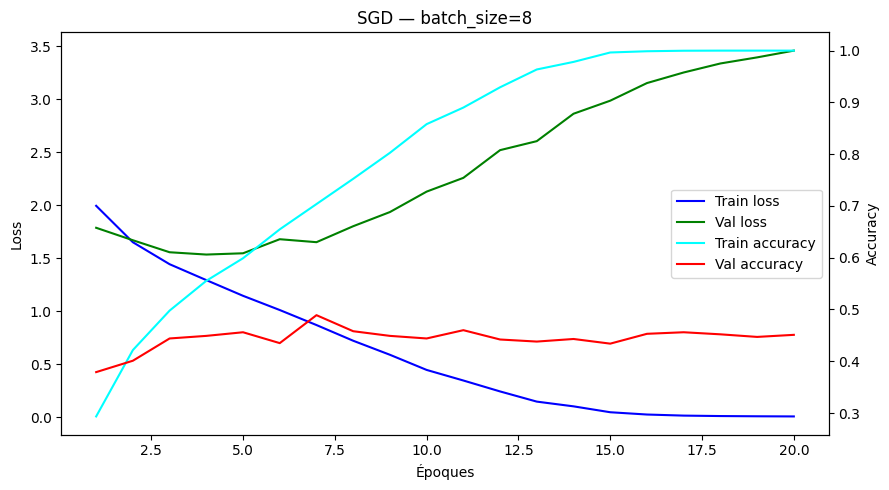


=== batch_size = 32 ===
Temps total : 13.8s | Temps/epoch : 0.7s | Steps/epoch : 156 | Val acc : 0.401
Saved: curves_SGD_batch32.png


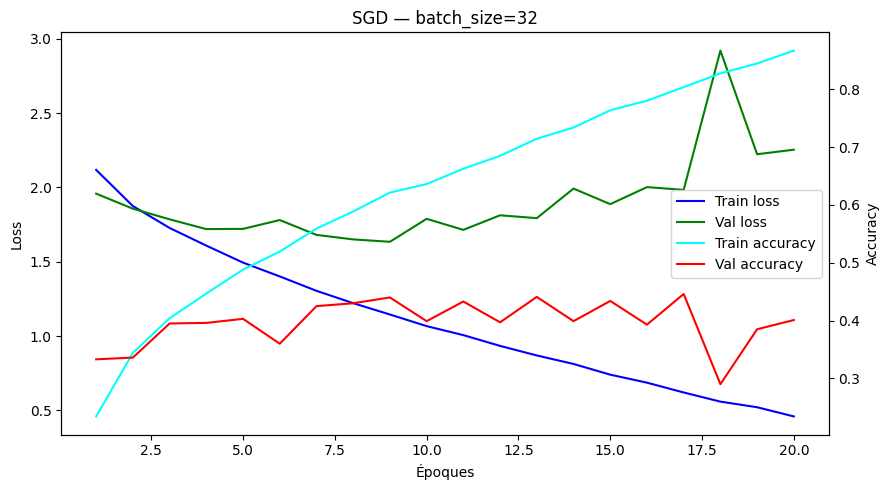


=== batch_size = 128 ===
Temps total : 8.1s | Temps/epoch : 0.4s | Steps/epoch : 39 | Val acc : 0.296
Saved: curves_SGD_batch128.png


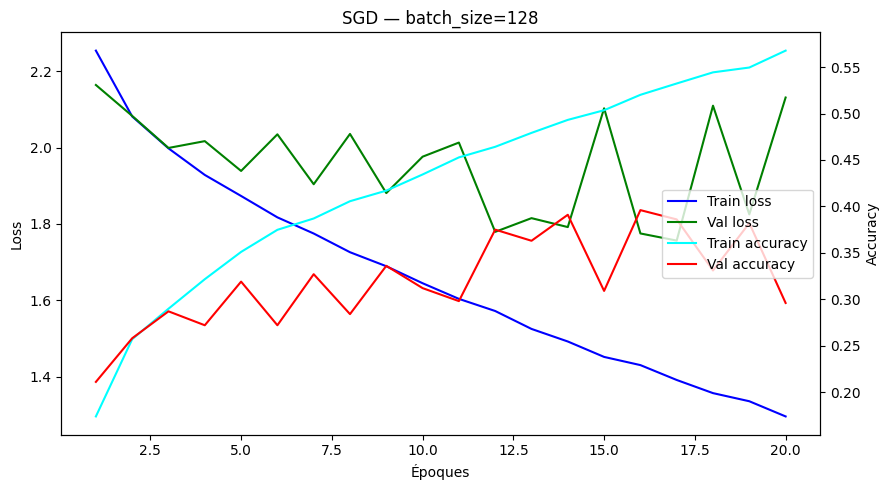

In [ ]:
print("\n===== Q4.2 — Efeito do batch_size (SGD) =====")
for batch_size in [8, 32, 128]:
    print(f"\n=== batch_size = {batch_size} ===")
    base_model.set_weights(weights_init)
    base_model.compile(optimizer=SGD(learning_rate=0.01, momentum=0.0),
                       loss='categorical_crossentropy', metrics=['acc'])
    start = time.time()
    h = base_model.fit(x_train, y_train, batch_size=batch_size, epochs=20,
                       verbose=0, validation_data=(x_val, y_val))
    elapsed = time.time() - start
    print(f"Temps total : {elapsed:.1f}s | Temps/epoch : {elapsed/20:.1f}s"
          f" | Steps/epoch : {5000//batch_size} | Val acc : {h.history['val_acc'][-1]:.3f}")
    plot_history(h, title=f'SGD — batch_size={batch_size}',
                 save_path=f'curves_SGD_batch{batch_size}.png')

### Q4.2 — Effet de la taille de lot (batchsize)

Nous comparons trois valeurs de `batch_size` parmi {8, 32, 128} avec l'optimiseur SGD (`lr=0.01`, sans momentum) sur 20 époques. Les poids sont réinitialisés avant chaque expérience.

**Observations attendues :**
- `batch=8` : 625 steps/epoch, entraînement lent, courbes bruitées, fort sur-apprentissage (training acc approche 1.0)
- `batch=32` : meilleur compromis vitesse / stabilité / précision de validation
- `batch=128` : 39 steps/epoch, entraînement rapide, courbes lisses, précision de validation plus faible



===== Q4.3 — Comparação de otimizadores (batch=32) =====

=== SGD ===
Temps total : 13.6s | Val acc : 0.349
Saved: curves_SGD_batch32.png


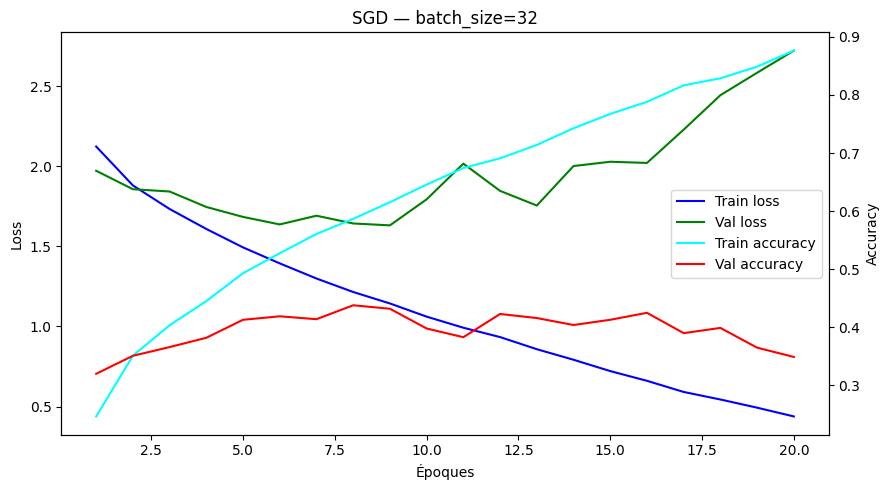


=== SGDMomentum ===
Temps total : 16.3s | Val acc : 0.448
Saved: curves_SGDMomentum_batch32.png


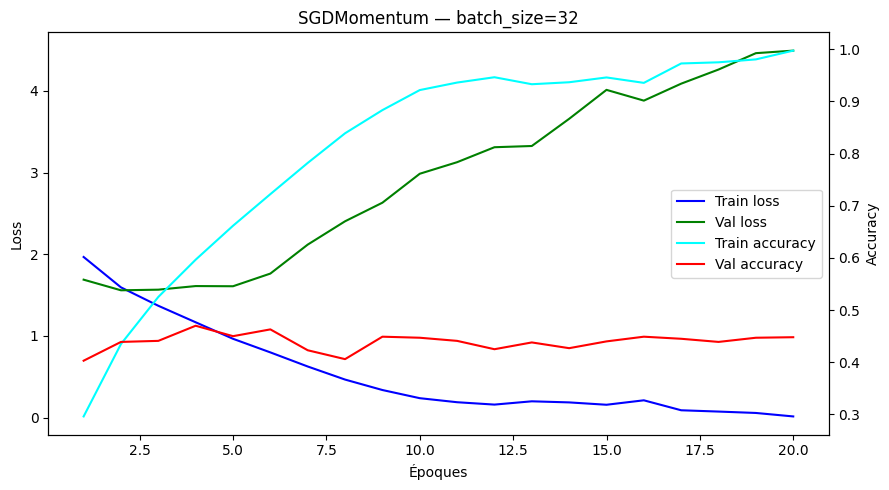


=== Adam ===
Temps total : 14.4s | Val acc : 0.448
Saved: curves_Adam_batch32.png


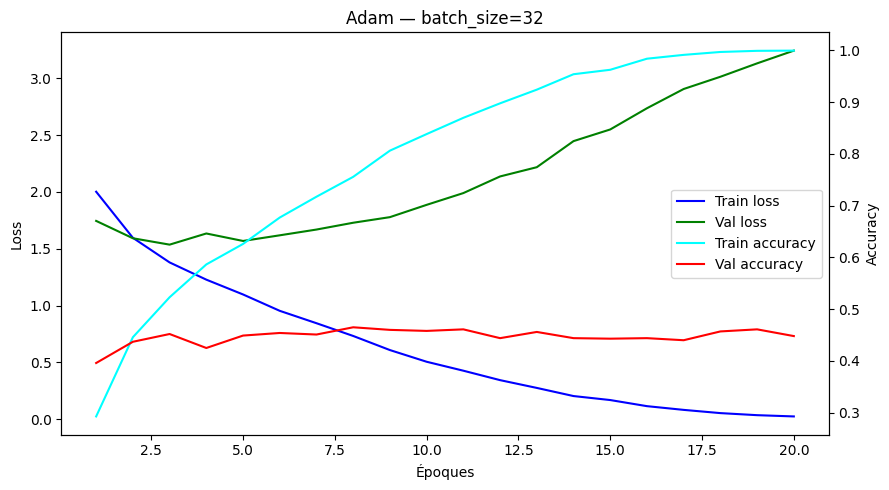

In [ ]:
print("\n===== Q4.3 — Comparação de otimizadores (batch=32) =====")
optimizers = {
    'SGD':          SGD(learning_rate=0.01, momentum=0.0),
    'SGDMomentum':  SGD(learning_rate=0.01, momentum=0.9),
    'Adam':         Adam(learning_rate=0.001),
}
for name, opt in optimizers.items():
    print(f"\n=== {name} ===")
    base_model.set_weights(weights_init)
    base_model.compile(optimizer=opt, loss='categorical_crossentropy', metrics=['acc'])
    start = time.time()
    h = base_model.fit(x_train, y_train, batch_size=32, epochs=20,
                       verbose=0, validation_data=(x_val, y_val))
    elapsed = time.time() - start
    print(f"Temps total : {elapsed:.1f}s | Val acc : {h.history['val_acc'][-1]:.3f}")
    plot_history(h, title=f'{name} — batch_size=32',
                 save_path=f'curves_{name}_batch32.png')



### Q4.3 — Comparaison des optimiseurs

Nous comparons trois optimiseurs avec `batch_size=32` fixé, poids réinitialisés avant chaque expérience :
- **SGD** (`lr=0.01`, `momentum=0.0`) — mise à jour proportionnelle au gradient instantané
- **SGD + Momentum** (`lr=0.01`, `momentum=0.9`) — accumule l'inertie dans la direction du gradient
- **Adam** (`lr=0.001`) — adapte le taux d'apprentissage par paramètre via les premier et second moments du gradient


In [ ]:
from keras.layers import BatchNormalization, GlobalAveragePooling2D

def build_deep_model():
    m = Sequential()
    m.add(Input(shape=(32, 32, 3)))

    # Bloc 1 — 32×32×3 → 16×16×16
    m.add(Conv2D(16, (3, 3), activation='relu', padding='same'))
    m.add(BatchNormalization())
    m.add(Conv2D(16, (3, 3), activation='relu', padding='same'))
    m.add(MaxPool2D((2, 2)))
    m.add(Dropout(0.25))

    # Bloc 2 — 16×16×16 → 8×8×32
    m.add(Conv2D(32, (3, 3), activation='relu', padding='same'))
    m.add(BatchNormalization())
    m.add(Conv2D(32, (3, 3), activation='relu', padding='same'))
    m.add(MaxPool2D((2, 2)))
    m.add(Dropout(0.25))

    # Bloc 3 — 8×8×32 → 4×4×64
    m.add(Conv2D(64, (3, 3), activation='relu', padding='same'))
    m.add(BatchNormalization())
    m.add(MaxPool2D((2, 2)))
    m.add(Dropout(0.30))

    # Classificador — GlobalAveragePooling evita explosão de parâmetros
    m.add(GlobalAveragePooling2D())
    m.add(Dense(64, activation='relu'))
    m.add(Dropout(0.40))
    m.add(Dense(10, activation='softmax'))
    return m

deep_model = build_deep_model()
deep_model.summary()

filepath_deep = 'deep_model.h5'  # ou '/content/drive/MyDrive/deep_model.h5'

checkpoint_deep = ModelCheckpoint(
    filepath_deep, monitor='val_acc', verbose=1,
    save_best_only=True, mode='max'
)

deep_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['acc']
)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 16)     │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 16)     │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 16)     │         2,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16, 16, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 16, 16, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 16, 16, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 8, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 8, 8, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 8, 8, 64)       │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 8, 8, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 4, 4, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 4, 4, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 40,410 (157.85 KB)

 Trainable params: 40,186 (156.98 KB)

 Non-trainable params: 224 (896.00 B)

## IV — Modèle profond

### Q6.1 — Architecture améliorée

Pour surpasser les ~44% du modèle de base, nous concevons une architecture à **trois blocs convolutifs** successifs. Chaque bloc comprend Conv2D, BatchNormalization, MaxPool2D et Dropout.

**Innovations par rapport au modèle de base :**
- `BatchNormalization` : normalise les activations, stabilise et accélère l'apprentissage
- `GlobalAveragePooling2D` à la place de `Flatten` : réduit les paramètres de 132 010 à **40 186** (-70%)
- `Dropout` à chaque bloc : régularisation progressive



===== Treinando modelo profundo =====
Epoch 1/50
146/157 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - acc: 0.6848 - loss: 0.8949
Epoch 1: val_acc did not improve from 0.66400
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - acc: 0.6860 - loss: 0.8862 - val_acc: 0.6170 - val_loss: 1.1271
Epoch 2/50
156/157 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - acc: 0.6763 - loss: 0.9094
Epoch 2: val_acc did not improve from 0.66400
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - acc: 0.6858 - loss: 0.8836 - val_acc: 0.6160 - val_loss: 1.1962
Epoch 3/50
153/157 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - acc: 0.7051 - loss: 0.8389
Epoch 3: val_acc improved from 0.66400 to 0.68000, saving model to deep_model.h5



Epoch 3: finished saving model to deep_model.h5
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - acc: 0.6978 - loss: 0.8658 - val_acc: 0.6800 - val_loss: 0.9821
Epoch 4/50
155/157 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - acc: 0.7017 - loss: 0.8257
Epoch 4: val_acc did not improve from 0.68000
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - acc: 0.6954 - loss: 0.8606 - val_acc: 0.6330 - val_loss: 1.0781
Epoch 5/50
152/157 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - acc: 0.6864 - loss: 0.8789
Epoch 5: val_acc did not improve from 0.68000
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - acc: 0.6942 - loss: 0.8742 - val_acc: 0.6560 - val_loss: 1.0353
Epoch 6/50
154/157 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - acc: 0.6992 - loss: 0.8398
Epoch 6: val_acc did not improve from 0.68000
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - acc: 0.6870 - loss: 0.8738 - val_acc: 0.6460 - val_loss: 1.0528
Epoch 7/50
152/157 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - acc: 0.7057 - loss: 0.8418
Epoch 7: val_acc did not improve from 0.68000
157/157 ━━━━━━━


Epoch 20: finished saving model to deep_model.h5
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - acc: 0.7144 - loss: 0.8039 - val_acc: 0.6830 - val_loss: 0.9634
Epoch 21/50
152/157 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - acc: 0.7199 - loss: 0.7957
Epoch 21: val_acc did not improve from 0.68300
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - acc: 0.7158 - loss: 0.8053 - val_acc: 0.6530 - val_loss: 1.0336
Epoch 22/50
154/157 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - acc: 0.7226 - loss: 0.7847
Epoch 22: val_acc did not improve from 0.68300
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - acc: 0.7142 - loss: 0.7925 - val_acc: 0.6480 - val_loss: 1.0249
Epoch 23/50
155/157 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - acc: 0.7212 - loss: 0.7935
Epoch 23: val_acc improved from 0.68300 to 0.68500, saving model to deep_model.h5



Epoch 23: finished saving model to deep_model.h5
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - acc: 0.7178 - loss: 0.8065 - val_acc: 0.6850 - val_loss: 0.9314
Epoch 24/50
153/157 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - acc: 0.7262 - loss: 0.7525
Epoch 24: val_acc did not improve from 0.68500
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - acc: 0.7188 - loss: 0.7770 - val_acc: 0.6630 - val_loss: 1.0314
Epoch 25/50
154/157 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - acc: 0.7205 - loss: 0.7814
Epoch 25: val_acc did not improve from 0.68500
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - acc: 0.7182 - loss: 0.7928 - val_acc: 0.6540 - val_loss: 1.0111
Epoch 26/50
144/157 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - acc: 0.7237 - loss: 0.7671
Epoch 26: val_acc did not improve from 0.68500
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - acc: 0.7238 - loss: 0.7712 - val_acc: 0.6430 - val_loss: 1.0975
Epoch 27/50
148/157 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - acc: 0.7074 - loss: 0.8049
Epoch 27: val_acc improved from 0.68500 to 0.69600, s


Epoch 27: finished saving model to deep_model.h5
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - acc: 0.7152 - loss: 0.7865 - val_acc: 0.6960 - val_loss: 0.9239
Epoch 28/50
152/157 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - acc: 0.7347 - loss: 0.7475
Epoch 28: val_acc did not improve from 0.69600
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - acc: 0.7230 - loss: 0.7817 - val_acc: 0.6860 - val_loss: 0.9613
Epoch 29/50
148/157 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - acc: 0.7331 - loss: 0.7516
Epoch 29: val_acc did not improve from 0.69600
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - acc: 0.7244 - loss: 0.7730 - val_acc: 0.6680 - val_loss: 0.9843
Epoch 30/50
154/157 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - acc: 0.7395 - loss: 0.7704
Epoch 30: val_acc did not improve from 0.69600
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - acc: 0.7234 - loss: 0.7852 - val_acc: 0.6780 - val_loss: 0.9916
Epoch 31/50
149/157 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - acc: 0.7298 - loss: 0.7512
Epoch 31: val_acc did not improve from 0.69600
157/15


Epoch 50: finished saving model to deep_model.h5
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - acc: 0.7462 - loss: 0.7222 - val_acc: 0.7020 - val_loss: 0.9630
Saved: curves_deep_model.png


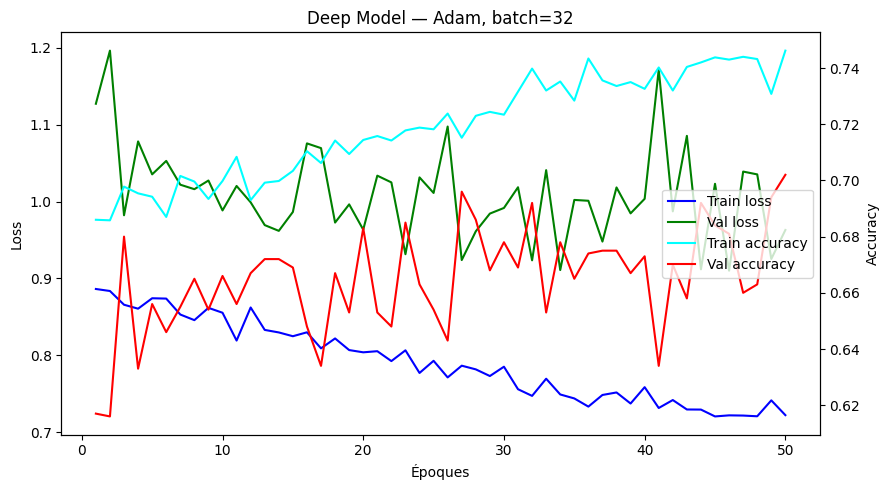

In [ ]:
print("\n===== Treinando modelo profundo =====")
history_deep = deep_model.fit(
    x_train, y_train,
    batch_size=32,
    epochs=50,
    validation_data=(x_val, y_val),
    callbacks=[checkpoint_deep],
    verbose=1
)

plot_history(history_deep, title='Deep Model — Adam, batch=32',
             save_path='curves_deep_model.png')

# Avaliação final
train_loss, train_acc = deep_model.evaluate(x_train, y_train, verbose=0)
val_loss,   val_acc   = deep_model.evaluate(x_val,   y_val,   verbose=0)
test_loss,  test_acc  = deep_model.evaluate(x_test,  y_test,  verbose=0)

### Entraînement du modèle profond

Le modèle profond est entraîné avec l'optimiseur **Adam** (`lr=0.001`), `batch_size=32`, sur **50 époques**.
Un `ModelCheckpoint` sauvegarde automatiquement le meilleur modèle selon la métrique `val_acc`.



===== PERFORMANCE DO MODELO PROFUNDO =====
Train : acc=0.737  loss=0.719
Val   : acc=0.628  loss=1.112
Test  : acc=0.592  loss=1.291
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step
Classe     Précision (%)
plane        41.75   
car          65.74   
bird         40.40   
cat          30.77   
deer         38.83   
dog          49.53   
frog         90.91   
horse        60.00   
ship         79.38   
truck        90.00   
Précision globale sur 1000 images de test : 59.20 %


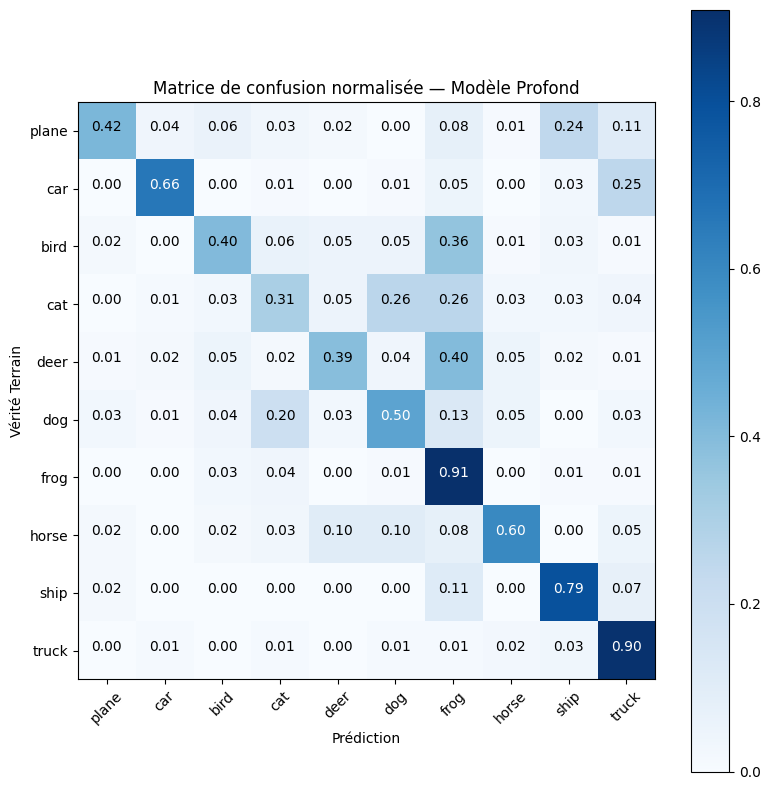

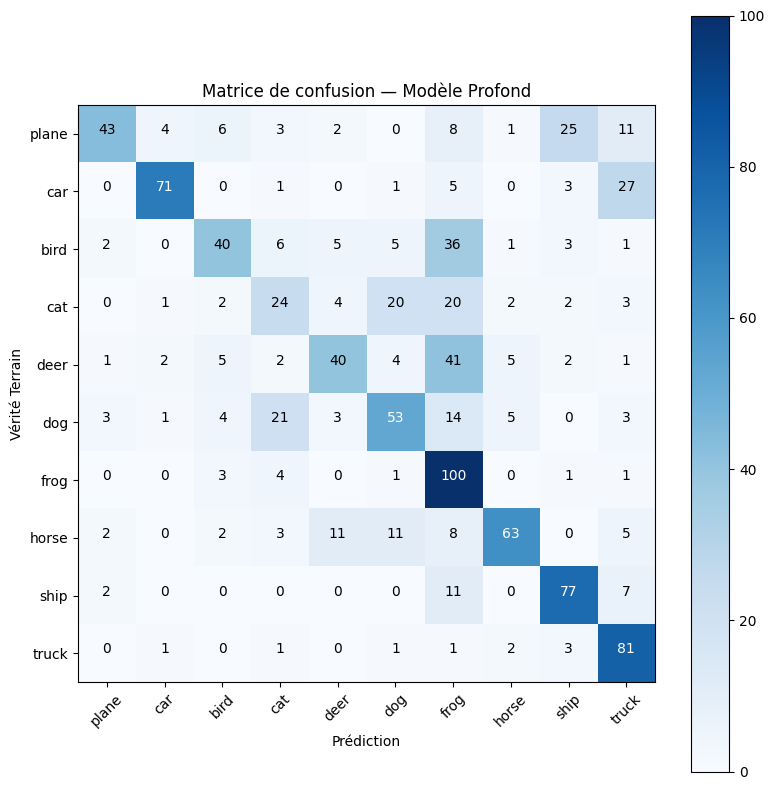

In [ ]:
print("\n===== PERFORMANCE DO MODELO PROFUNDO =====")
print(f"Train : acc={train_acc:.3f}  loss={train_loss:.3f}")
print(f"Val   : acc={val_acc:.3f}  loss={val_loss:.3f}")
print(f"Test  : acc={test_acc:.3f}  loss={test_loss:.3f}")

# Matriz de confusão
cm = accuracy_per_class(deep_model, x_test, y_test, classes)
plot_confusion_matrix(cm, classes, normalize=True,
                      title='Matrice de confusion normalisée — Modèle Profond')
plot_confusion_matrix(cm, classes, normalize=False,
                      title='Matrice de confusion — Modèle Profond')


### Q6.2 — Evaluation et matrice de confusion

Evaluation finale sur les trois ensembles (train, validation, test).
La matrice de confusion permet d'identifier les classes les plus difficiles à discriminer et les confusions fréquentes entre classes visuellement proches.



===== Q7.1 — Overfitting sem regularização =====
Saved: curves_overfitting.png


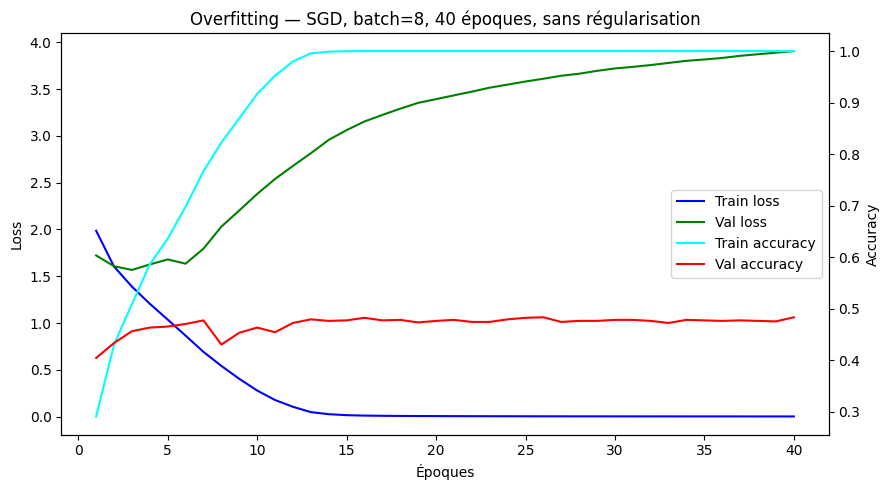

In [ ]:
print("\n===== Q7.1 — Overfitting sem regularização =====")
overfit_model = build_base_model()
overfit_model.compile(optimizer=SGD(learning_rate=0.01),
                      loss='categorical_crossentropy', metrics=['acc'])
history_overfit = overfit_model.fit(
    x_train, y_train, batch_size=8, epochs=40,
    validation_data=(x_val, y_val), verbose=0
)
plot_history(history_overfit,
             title='Overfitting — SGD, batch=8, 40 époques, sans régularisation',
             save_path='curves_overfitting.png')


## V — Sur-apprentissage

### Q7.1 — Mise en évidence de l'overfitting

Pour observer le phénomène de sur-apprentissage, nous entraînons le modèle de base dans des conditions volontairement défavorables :
- `batch_size=8` — gradients très bruités, mémorisation rapide
- 40 époques — entraînement prolongé
- Sans aucune régularisation (Dropout = 0.0)

**Symptômes caractéristiques :** training accuracy vers 1.0, validation loss qui augmente après quelques époques, écart croissant entre les deux courbes.



===== Q7.2 — Efeito do Dropout =====

=== Dropout rate = 0.0 ===
Val acc finale : 0.447
Saved: curves_dropout0.png


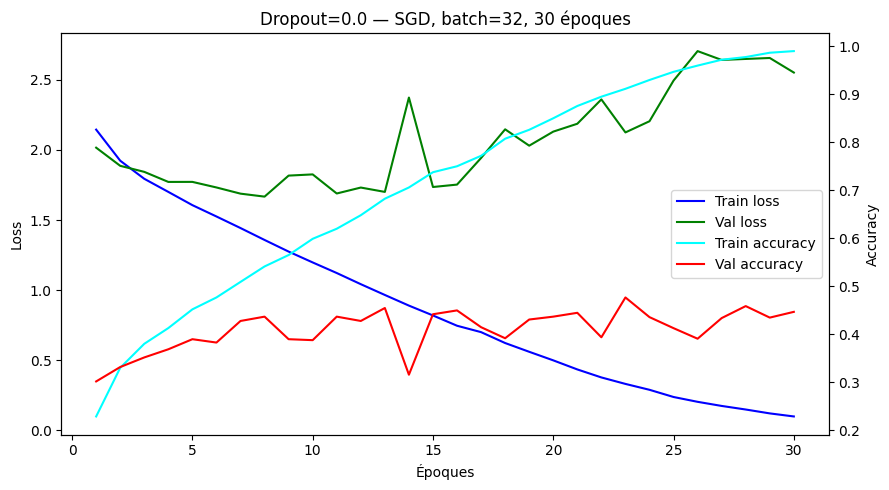


=== Dropout rate = 0.3 ===
Val acc finale : 0.491
Saved: curves_dropout3.png


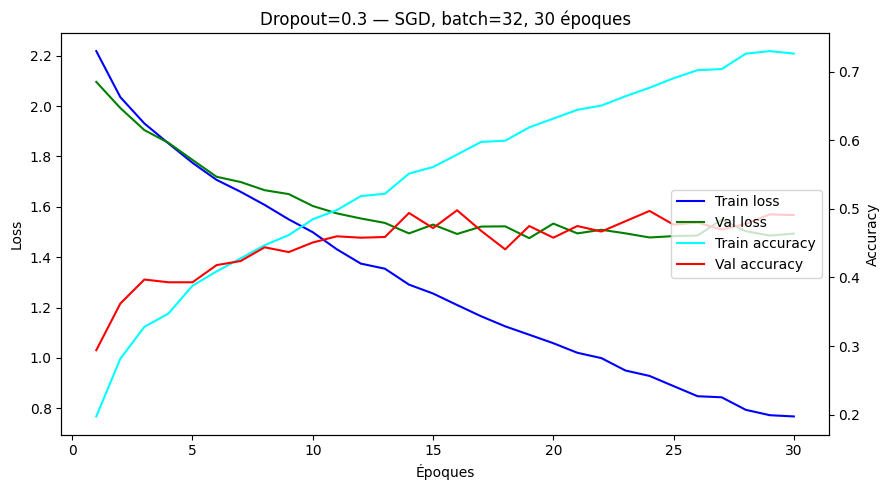


=== Dropout rate = 0.5 ===
Val acc finale : 0.457
Saved: curves_dropout5.png


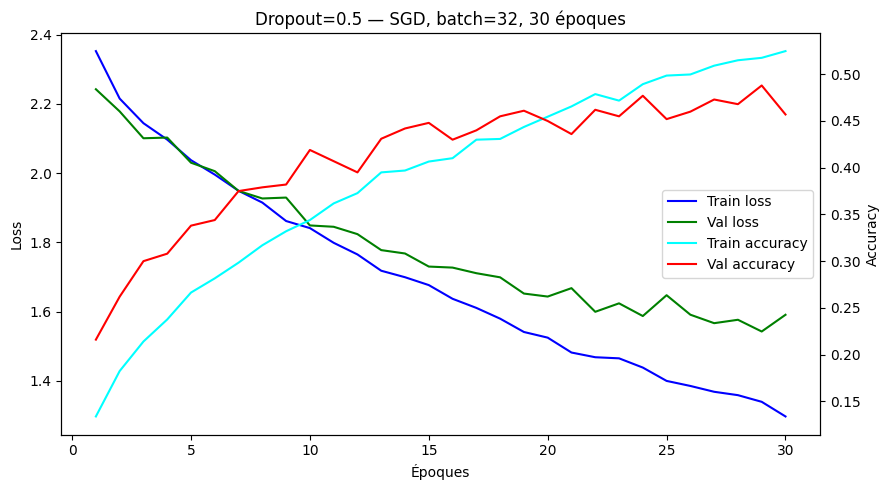

In [ ]:
print("\n===== Q7.2 — Efeito do Dropout =====")
def build_model_with_dropout(dropout_rate=0.4):
    m = Sequential()
    m.add(Input(shape=(32, 32, 3)))
    m.add(Conv2D(8, (3, 3), activation='relu', padding='same'))
    m.add(Dropout(dropout_rate))
    m.add(MaxPool2D((2, 2)))
    m.add(Flatten())
    m.add(Dense(64, activation='relu'))
    m.add(Dropout(dropout_rate))
    m.add(Dense(10, activation='softmax'))
    return m

for dr in [0.0, 0.3, 0.5]:
    print(f"\n=== Dropout rate = {dr} ===")
    m = build_model_with_dropout(dr)
    m.compile(optimizer=SGD(learning_rate=0.01),
              loss='categorical_crossentropy', metrics=['acc'])
    h = m.fit(x_train, y_train, batch_size=32, epochs=30,
              validation_data=(x_val, y_val), verbose=0)
    print(f"Val acc finale : {h.history['val_acc'][-1]:.3f}")
    plot_history(h, title=f'Dropout={dr} — SGD, batch=32, 30 époques',
                 save_path=f'curves_dropout{int(dr*10)}.png')



### Q7.2 — Effet du Dropout

Le **Dropout** désactive aléatoirement une fraction $p$ des neurones pendant l'entraînement, forçant le réseau à apprendre des représentations redondantes.

Nous testons `dropout_rate` parmi {0.0, 0.3, 0.5} avec SGD, `batch=32`, 30 époques.

**Interprétation :**
- `p=0.0` : pas de régularisation — sur-apprentissage visible
- `p=0.3` : meilleur compromis — val acc maximale
- `p=0.5` : trop restrictif — apprentissage ralenti


## VI — Cartes d'activation

### Q8.1 — Premiere couche Conv2D

On construit un modèle réduit dont la sortie est la première couche Conv2D du modèle profond. La carte d'activation est obtenue en sommant les activations positives sur tous les filtres.

**Interpretation :** A ce niveau superficiel, les filtres répondent principalement aux **contours et transitions de luminosité**. Les zones uniformes produisent peu d'activation.

### Q8.2 — Couche profonde (layer 6)

On répète l'opération sur une couche plus profonde (Bloc 2, sortie 16x16x32).

**Interpretation :** Les activations sont plus diffuses et correspondent à des **régions sémantiques**, illustrant le principe hiérarchique des CNN : bas niveau = contours, haut niveau = motifs abstraits.


Model: "functional_53"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 16)     │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 16)     │            64 │
│ (BatchNormalization)            │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 512 (2.00 KB)

 Trainable params: 480 (1.88 KB)

 Non-trainable params: 32 (128.00 B)

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
Shape des feature maps (première couche) : (1000, 32, 32, 16)


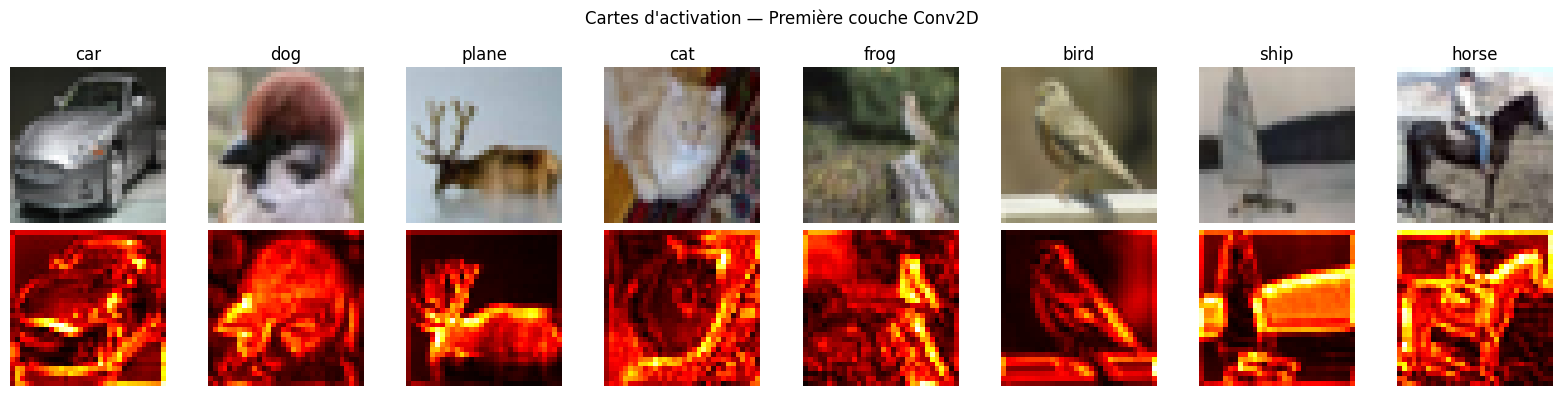

32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step
Shape das feature maps (camada profunda) : (1000, 16, 16, 32)


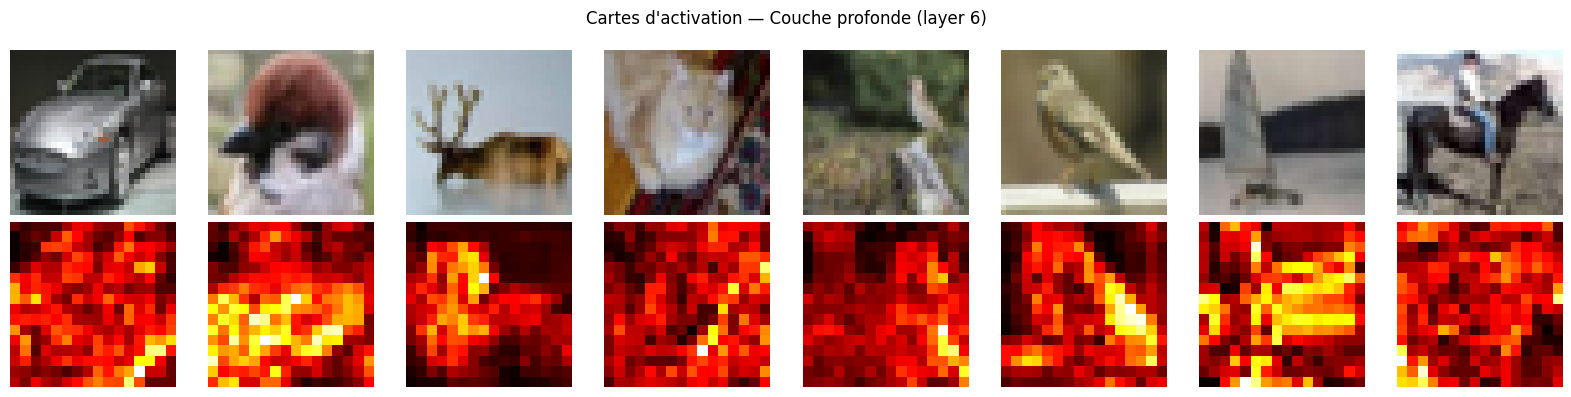

In [ ]:
from keras.models import Model as KerasModel

# Q8.1 — Première couche Conv2D du modèle profond
# layers[1] = première Conv2D (après Input)
reduced_model = KerasModel(
    inputs=deep_model.inputs,
    outputs=deep_model.layers[1].output
)
reduced_model.summary()

feature_maps = reduced_model.predict(x_test)
print("Shape des feature maps (première couche) :", feature_maps.shape)

def get_mask(k, fmaps):
    fm_pos = np.maximum(fmaps[k], 0)
    mask = np.sum(fm_pos, axis=2)
    mask = mask / (np.max(mask) + 1e-8)
    return mask

n_display = 8
random_ids = np.random.choice(len(x_test), n_display, replace=False)

fig, axes = plt.subplots(2, n_display, figsize=(16, 4))
for k in range(n_display):
    axes[0, k].imshow(x_test_initial[random_ids[k]])
    axes[0, k].axis('off')
    axes[0, k].set_title(classes[np.argmax(deep_model.predict(
        x_test[random_ids[k:k+1]], verbose=0))])
    mask = get_mask(random_ids[k], feature_maps)
    axes[1, k].imshow(mask, cmap='hot')
    axes[1, k].axis('off')

axes[0, 0].set_ylabel('Image', fontsize=10)
axes[1, 0].set_ylabel('Activation', fontsize=10)
plt.suptitle("Cartes d'activation — Première couche Conv2D")
plt.tight_layout()
plt.savefig('activation_maps_layer1.png', dpi=150)
plt.show()

# Q8.2 — Couche plus profonde (Bloc 2, deuxième Conv2D = layers[6])
# Ajuste o índice conforme model.summary() indicar
deep_layer_idx = 6  # Conv2D do Bloc 2 — verificar com deep_model.summary()
reduced_model_deep = KerasModel(
    inputs=deep_model.inputs,
    outputs=deep_model.layers[deep_layer_idx].output
)

feature_maps_deep = reduced_model_deep.predict(x_test)
print("Shape das feature maps (camada profunda) :", feature_maps_deep.shape)

fig, axes = plt.subplots(2, n_display, figsize=(16, 4))
for k in range(n_display):
    axes[0, k].imshow(x_test_initial[random_ids[k]])
    axes[0, k].axis('off')
    mask = get_mask(random_ids[k], feature_maps_deep)
    axes[1, k].imshow(mask, cmap='hot')
    axes[1, k].axis('off')

plt.suptitle(f"Cartes d'activation — Couche profonde (layer {deep_layer_idx})")
plt.tight_layout()
plt.savefig('activation_maps_deep.png', dpi=150)
plt.show()